<a href="https://colab.research.google.com/github/zeosapka/glass-box-ai-research/blob/main/glass-box-ai-research%20/notebooks/07_multiseed_circuit_replication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# DENEY 6 — ÇOKLU SEED DEVRE TEKRARI
# Amaç:
# Hafta 1'de gözlenen aday devre etkisinin farklı random
# seed değerlerinde tekrarlanıp tekrarlanmadığını test etmek.
# ============================================================

import random
import numpy as np
import torch

# Kullanılacak bağımsız seed değerleri.
# Seed=42, Hafta 1'deki referans deneydir.
SEEDS = [42, 0, 7, 123, 2024]

# MNIST MLP mimarisi.
INPUT_SIZE = 784
HIDDEN_SIZE_1 = 128
HIDDEN_SIZE_2 = 64
OUTPUT_SIZE = 10

# Hafta 1 ile aynı eğitim ayarlarını koruyoruz.
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 5

# Deney 6 başarı kriteri.
SUCCESS_THRESHOLD_PP = -5.0
RANDOM_CONTROL_RATIO = 3.0

print("Deney 6 hazır.")
print("Seed'ler:", SEEDS)
print("Mimari:", INPUT_SIZE, "→", HIDDEN_SIZE_1, "→", HIDDEN_SIZE_2, "→", OUTPUT_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Epoch:", EPOCHS)
print("Class 0 etki eşiği:", SUCCESS_THRESHOLD_PP, "puan")
print("Random control oranı:", RANDOM_CONTROL_RATIO, "×")

Deney 6 hazır.
Seed'ler: [42, 0, 7, 123, 2024]
Mimari: 784 → 128 → 64 → 10
Learning rate: 0.001
Batch size: 64
Epoch: 5
Class 0 etki eşiği: -5.0 puan
Random control oranı: 3.0 ×


In [2]:
# ============================================================
# DENEY 6 — SEED KONTROLÜ
# Amaç:
# Her deney tekrarında Python, NumPy ve PyTorch kaynaklı
# rastgelelikleri aynı seed üzerinden kontrol etmek.
# Böylece farklı seed sonuçlarını karşılaştırabiliriz.
# ============================================================

def set_seed(seed):
    """
    Deneyin tüm rastgele işlemlerini verilen seed ile
    mümkün olduğunca tekrarlanabilir hale getirir.
    """

    # Python'un rastgele sayı üretimini sabitler.
    random.seed(seed)

    # NumPy'nin rastgele sayı üretimini sabitler.
    np.random.seed(seed)

    # PyTorch CPU rastgeleliğini sabitler.
    torch.manual_seed(seed)

    # Eğer GPU kullanılabiliyorsa GPU rastgeleliğini de sabitler.
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# Fonksiyonun çalıştığını kontrol ediyoruz.
set_seed(42)

print("Seed kontrol fonksiyonu hazır.")
print("Test edilen seed:", 42)

Seed kontrol fonksiyonu hazır.
Test edilen seed: 42


In [3]:
# ============================================================
# DENEY 6 — MNIST MLP MODELİ
# Amaç:
# Hafta 1'de kullanılan 784 → 128 → 64 → 10
# mimarisini aynı şekilde yeniden oluşturmak.
# ============================================================

import torch.nn as nn


class MNIST_MLP(nn.Module):
    """
    MNIST için kullanılan küçük çok katmanlı algılayıcı (MLP).

    Mimari:
    784 → 128 → 64 → 10
    """

    def __init__(self):
        super().__init__()

        # İlk gizli katman:
        # 784 giriş pikselini 128 özelliğe dönüştürür.
        self.fc1 = nn.Linear(INPUT_SIZE, HIDDEN_SIZE_1)

        # İkinci gizli katman:
        # 128 özelliği 64 özelliğe dönüştürür.
        self.fc2 = nn.Linear(HIDDEN_SIZE_1, HIDDEN_SIZE_2)

        # Çıkış katmanı:
        # 64 özelliği 10 sınıf skoruna dönüştürür.
        self.fc3 = nn.Linear(HIDDEN_SIZE_2, OUTPUT_SIZE)

        # Aktivasyon fonksiyonu:
        # Negatif değerleri sıfırlayarak doğrusal olmayanlık sağlar.
        self.relu = nn.ReLU()

    def forward(self, x):
        # 28×28 görüntüyü 784 elemanlı vektöre çevirir.
        x = x.view(x.size(0), -1)

        # Birinci gizli katman + ReLU.
        x = self.relu(self.fc1(x))

        # İkinci gizli katman + ReLU.
        x = self.relu(self.fc2(x))

        # 10 sınıf için son çıktı skorlarını üretir.
        x = self.fc3(x)

        return x


# Modeli oluştur.
model = MNIST_MLP()

print(model)

MNIST_MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


In [4]:
# ============================================================
# DENEY 6 — MNIST VERİ SETİNİN HAZIRLANMASI
# Amaç:
# Hafta 1'de kullanılan MNIST eğitim ve test veri setlerini
# aynı temel koşullarla yüklemek.
# ============================================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Görüntüleri PyTorch tensörüne dönüştürür.
transform = transforms.ToTensor()

# MNIST eğitim veri setini indirir/yükler.
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# MNIST test veri setini indirir/yükler.
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Eğitim verilerini mini-batch'ler halinde kullanacağız.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Test verilerinde karıştırma yapmıyoruz.
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("MNIST hazır.")
print("Eğitim örneği:", len(train_dataset))
print("Test örneği:", len(test_dataset))
print("Batch size:", BATCH_SIZE)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 496kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.76MB/s]

MNIST hazır.
Eğitim örneği: 60000
Test örneği: 10000
Batch size: 64


In [7]:
# ============================================================
# DENEY 6 — MODEL EĞİTİM FONKSİYONU
# Amaç:
# Verilen seed ile modeli oluşturmak, Hafta 1 ile aynı
# eğitim ayarlarıyla eğitmek ve test doğruluğunu ölçmek.
# ============================================================

import torch.optim as optim


def train_model(seed):
    """
    Verilen seed ile yeni bir MNIST_MLP oluşturur,
    modeli 5 epoch eğitir ve test doğruluğunu döndürür.
    """

    # Bu seed için tüm rastgele işlemleri sabitler.
    set_seed(seed)

    # Her seed için sıfırdan yeni model oluşturulur.
    model = MNIST_MLP()

    # Hafta 1'de kullanılan Adam optimizer.
    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    # Sınıflandırma problemi için Cross Entropy Loss.
    criterion = nn.CrossEntropyLoss()

    # Modeli eğitim moduna geçirir.
    model.train()

    # Belirlenen epoch sayısı kadar eğitim yapılır.
    for epoch in range(EPOCHS):

        # Her epoch başında toplam loss sıfırlanır.
        total_loss = 0.0

        # Eğitim verileri batch'ler halinde işlenir.
        for images, labels in train_loader:

            # Önceki adımın gradient'lerini temizler.
            optimizer.zero_grad()

            # Model tahmini.
            outputs = model(images)

            # Tahmin ile gerçek etiket arasındaki hatayı hesaplar.
            loss = criterion(outputs, labels)

            # Geri yayılım (backpropagation).
            loss.backward()

            # Ağırlıkları günceller.
            optimizer.step()

            # Epoch loss değerine mevcut batch loss'unu ekler.
            total_loss += loss.item()

        # Epoch sonunda ortalama loss'u hesaplar.
        average_loss = total_loss / len(train_loader)

        print(
            f"Seed {seed} | "
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"Loss: {average_loss:.4f}"
        )

    # Modeli değerlendirme moduna geçirir.
    model.eval()

    correct = 0
    total = 0

    # Test sırasında gradient hesaplamaya gerek yoktur.
    with torch.no_grad():

        for images, labels in test_loader:

            # Test tahmini.
            outputs = model(images)

            # En yüksek skorlu sınıfı tahmin olarak seçer.
            predictions = outputs.argmax(dim=1)

            # Doğru tahminleri sayar.
            correct += (predictions == labels).sum().item()

            # Toplam örnek sayısını günceller.
            total += labels.size(0)

    # Test doğruluğunu yüzde olarak hesaplar.
    test_accuracy = 100.0 * correct / total

    print(f"Seed {seed} | Test Accuracy: {test_accuracy:.2f}%")

    return model, test_accuracy

In [8]:
# ============================================================
# DENEY 6 — REFERANS SEED 42 EĞİTİMİ
# Amaç:
# Hafta 1'deki referans seed olan 42 ile modeli eğitmek
# ve test doğruluğunu ölçmek.
# ============================================================

model_42, accuracy_42 = train_model(42)

print("\nSeed 42 eğitimi tamamlandı.")
print(f"Test doğruluğu: {accuracy_42:.2f}%")

Seed 42 | Epoch 1/5 | Loss: 0.3328
Seed 42 | Epoch 2/5 | Loss: 0.1354
Seed 42 | Epoch 3/5 | Loss: 0.0945
Seed 42 | Epoch 4/5 | Loss: 0.0717
Seed 42 | Epoch 5/5 | Loss: 0.0558
Seed 42 | Test Accuracy: 97.56%

Seed 42 eğitimi tamamlandı.
Test doğruluğu: 97.56%


In [9]:
# ============================================================
# DENEY 6 — AKTİVASYONLARIN TOPLANMASI
# Amaç:
# İkinci gizli katmandaki 64 nöronun test verisindeki
# aktivasyonlarını toplayarak aday nöronları keşfetmeye
# hazırlık yapmak.
# ============================================================

# İkinci gizli katmanın çıktısını tutmak için liste.
activation_batches = []

# Modelin ikinci gizli katmanını yakalamak için hook.
def activation_hook(module, input, output):
    activation_batches.append(output.detach().cpu())

# fc2 katmanına forward hook ekliyoruz.
hook_handle = model_42.fc2.register_forward_hook(activation_hook)

# Test verisini modelden geçiriyoruz.
model_42.eval()

with torch.no_grad():
    for images, labels in test_loader:
        model_42(images)

# Hook'u artık kaldırıyoruz.
hook_handle.remove()

# Batch'leri tek bir aktivasyon matrisi haline getiriyoruz.
activations_42 = torch.cat(activation_batches, dim=0)

print("Aktivasyon toplama tamamlandı.")
print("Aktivasyon matrisi boyutu:", activations_42.shape)

Aktivasyon toplama tamamlandı.
Aktivasyon matrisi boyutu: torch.Size([10000, 64])


In [10]:
# ============================================================
# DENEY 6 — CLASS 0 NÖRON SEÇİCİLİĞİ
# Amaç:
# İkinci gizli katmandaki 64 nöron arasından Class 0'a
# daha seçici tepki veren aday nöronları belirlemek.
# ============================================================

# Test etiketlerini tek bir tensör halinde topluyoruz.
test_labels = torch.cat([
    labels for _, labels in test_loader
])

# Class 0 örneklerini seçiyoruz.
class0_mask = test_labels == 0

# Class 0 dışındaki örnekleri seçiyoruz.
non_class0_mask = test_labels != 0

# Her nöron için Class 0 ortalama aktivasyonu.
class0_mean = activations_42[class0_mask].mean(dim=0)

# Her nöron için Class 0 dışındaki sınıfların
# ortalama aktivasyonu.
non_class0_mean = activations_42[non_class0_mask].mean(dim=0)

# Seçicilik (selectivity):
# Class 0 aktivasyonu - diğer sınıfların aktivasyonu.
selectivity_42 = class0_mean - non_class0_mean

# En yüksek seçiciliğe sahip nöronları sıralıyoruz.
ranked_neurons_42 = torch.argsort(
    selectivity_42,
    descending=True
)

# İlk 10 adayı gösteriyoruz.
print("Seed 42 — Class 0 için en seçici 10 nöron:")

for rank, neuron_idx in enumerate(ranked_neurons_42[:10], start=1):
    idx = neuron_idx.item()

    print(
        f"{rank:2d}. Nöron {idx:2d} | "
        f"Class 0 ort.: {class0_mean[idx]:.4f} | "
        f"Diğer sınıflar ort.: {non_class0_mean[idx]:.4f} | "
        f"Seçicilik: {selectivity_42[idx]:.4f}"
    )

Seed 42 — Class 0 için en seçici 10 nöron:
 1. Nöron 47 | Class 0 ort.: 7.6086 | Diğer sınıflar ort.: 1.7915 | Seçicilik: 5.8170
 2. Nöron  1 | Class 0 ort.: 5.2329 | Diğer sınıflar ort.: 0.1488 | Seçicilik: 5.0841
 3. Nöron 17 | Class 0 ort.: 5.6797 | Diğer sınıflar ort.: 0.8783 | Seçicilik: 4.8014
 4. Nöron 59 | Class 0 ort.: 5.1979 | Diğer sınıflar ort.: 0.5372 | Seçicilik: 4.6607
 5. Nöron 57 | Class 0 ort.: 4.5574 | Diğer sınıflar ort.: 0.4293 | Seçicilik: 4.1281
 6. Nöron 28 | Class 0 ort.: 5.6615 | Diğer sınıflar ort.: 2.0585 | Seçicilik: 3.6030
 7. Nöron 53 | Class 0 ort.: 5.7233 | Diğer sınıflar ort.: 2.4750 | Seçicilik: 3.2483
 8. Nöron 45 | Class 0 ort.: 3.9515 | Diğer sınıflar ort.: 0.7431 | Seçicilik: 3.2084
 9. Nöron 39 | Class 0 ort.: 4.4759 | Diğer sınıflar ort.: 1.7595 | Seçicilik: 2.7164
10. Nöron  9 | Class 0 ort.: 2.9780 | Diğer sınıflar ort.: 0.8999 | Seçicilik: 2.0781


In [11]:
# ============================================================
# DENEY 6 — SEED 42 ADAY DEVRESİ
# Amaç:
# Class 0 seçiciliği en yüksek ilk 5 nöronu aday devre
# (candidate circuit) olarak belirlemek.
# ============================================================

# En yüksek seçiciliğe sahip ilk 5 nöronu alıyoruz.
candidate_circuit_42 = ranked_neurons_42[:5].tolist()

print("Seed 42 aday devresi:")
print(candidate_circuit_42)

print("\nSeçicilik değerleri:")

for neuron_idx in candidate_circuit_42:
    print(
        f"Nöron {neuron_idx:2d} → "
        f"Seçicilik: {selectivity_42[neuron_idx]:.4f}"
    )

Seed 42 aday devresi:
[47, 1, 17, 59, 57]

Seçicilik değerleri:
Nöron 47 → Seçicilik: 5.8170
Nöron  1 → Seçicilik: 5.0841
Nöron 17 → Seçicilik: 4.8014
Nöron 59 → Seçicilik: 4.6607
Nöron 57 → Seçicilik: 4.1281


In [12]:
# ============================================================
# DENEY 6 — ADAY DEVRE ABLASYONU
# Amaç:
# Seed 42 için keşfedilen aday nöronları devre dışı
# bıraktığımızda Class 0 doğruluğunun ne kadar değiştiğini
# ölçmek.
# ============================================================

def evaluate_class_accuracy(model, data_loader, target_class=0):
    """
    Belirli bir sınıfın doğruluğunu hesaplar.
    """

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:

            # Model tahmini.
            outputs = model(images)

            # En yüksek skorlu sınıfı tahmin olarak seç.
            predictions = outputs.argmax(dim=1)

            # Sadece hedef sınıfa ait örnekleri seç.
            mask = labels == target_class

            # Hedef sınıftaki toplam örnek sayısı.
            total += mask.sum().item()

            # Hedef sınıfta doğru tahmin edilen örnek sayısı.
            correct += (
                (predictions[mask] == labels[mask])
            ).sum().item()

    # Hedef sınıf doğruluğu.
    accuracy = 100.0 * correct / total

    return accuracy


def evaluate_with_ablation(
    model,
    data_loader,
    neurons,
    target_class=0
):
    """
    Belirtilen nöronları sıfırlayarak (ablation)
    hedef sınıf doğruluğunu ölçer.
    """

    model.eval()

    # Ablasyon sırasında kullanılacak hook.
    def ablation_hook(module, input, output):

        # Orijinal çıktıyı değiştirmeden önce kopyalıyoruz.
        modified_output = output.clone()

        # Seçilen nöronların aktivasyonlarını sıfırlıyoruz.
        modified_output[:, neurons] = 0.0

        return modified_output

    # fc2 katmanına ablasyon hook'u eklenir.
    hook_handle = model.fc2.register_forward_hook(ablation_hook)

    try:

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in data_loader:

                # Ablasyon uygulanmış model çıktısı.
                outputs = model(images)

                # Tahmin edilen sınıf.
                predictions = outputs.argmax(dim=1)

                # Sadece hedef sınıfı değerlendir.
                mask = labels == target_class

                total += mask.sum().item()

                correct += (
                    (predictions[mask] == labels[mask])
                ).sum().item()

    finally:

        # Hook'u mutlaka kaldırıyoruz.
        hook_handle.remove()

    accuracy = 100.0 * correct / total

    return accuracy


# Önce normal Class 0 doğruluğunu ölç.
baseline_class0_accuracy_42 = evaluate_class_accuracy(
    model_42,
    test_loader,
    target_class=0
)

# Daha sonra aday devreyi ablasyonla devre dışı bırak.
ablated_class0_accuracy_42 = evaluate_with_ablation(
    model_42,
    test_loader,
    candidate_circuit_42,
    target_class=0
)

# Değişimi yüzde puan cinsinden hesapla.
class0_effect_42 = (
    ablated_class0_accuracy_42
    - baseline_class0_accuracy_42
)

print("Seed 42 — Ablasyon sonucu")
print("--------------------------------")
print(
    f"Normal Class 0 doğruluğu: "
    f"{baseline_class0_accuracy_42:.4f}%"
)

print(
    f"Ablasyon sonrası Class 0 doğruluğu: "
    f"{ablated_class0_accuracy_42:.4f}%"
)

print(
    f"Etki: "
    f"{class0_effect_42:+.4f} yüzde puan"
)

Seed 42 — Ablasyon sonucu
--------------------------------
Normal Class 0 doğruluğu: 98.6735%
Ablasyon sonrası Class 0 doğruluğu: 83.7755%
Etki: -14.8980 yüzde puan


In [13]:
# ============================================================
# DENEY 6 — RANDOM CONTROL
# Amaç:
# Aday devrenin etkisinin sadece 5 nöronu kapatmaktan
# kaynaklanıp kaynaklanmadığını kontrol etmek.
# ============================================================

# Deneyin tekrarlanabilir olması için seed'i sabitliyoruz.
set_seed(42)

# Aday devre ile aynı sayıda rastgele nöron seçiyoruz.
random_control_42 = torch.randperm(HIDDEN_SIZE_2)[
    :len(candidate_circuit_42)
].tolist()

print("Seed 42 — Random control nöronları:")
print(random_control_42)

print("\nAday devre:")
print(candidate_circuit_42)

print(
    "\nHer iki gruptaki nöron sayısı:",
    len(candidate_circuit_42)
)

Seed 42 — Random control nöronları:
[38, 24, 48, 63, 10]

Aday devre:
[47, 1, 17, 59, 57]

Her iki gruptaki nöron sayısı: 5


In [14]:
# ============================================================
# DENEY 6 — RANDOM CONTROL ABLASYONU
# Amaç:
# Rastgele seçilen 5 nöronun ablasyon etkisini ölçmek
# ve aday devrenin etkisiyle karşılaştırmak.
# ============================================================

# Random control nöronlarını ablasyonla devre dışı bırak.
random_control_accuracy_42 = evaluate_with_ablation(
    model_42,
    test_loader,
    random_control_42,
    target_class=0
)

# Random control'ün Class 0 doğruluğundaki değişimini hesapla.
random_control_effect_42 = (
    random_control_accuracy_42
    - baseline_class0_accuracy_42
)

print("Seed 42 — Random Control sonucu")
print("--------------------------------")
print(
    f"Normal Class 0 doğruluğu: "
    f"{baseline_class0_accuracy_42:.4f}%"
)

print(
    f"Random control sonrası: "
    f"{random_control_accuracy_42:.4f}%"
)

print(
    f"Random control etkisi: "
    f"{random_control_effect_42:+.4f} yüzde puan"
)

print("\nKarşılaştırma")
print("--------------------------------")
print(
    f"Aday devre etkisi: "
    f"{class0_effect_42:+.4f} pp"
)

print(
    f"Random control etkisi: "
    f"{random_control_effect_42:+.4f} pp"
)

# Etki büyüklüklerini karşılaştırıyoruz.
if random_control_effect_42 != 0:
    effect_ratio_42 = abs(class0_effect_42) / abs(random_control_effect_42)
    print(
        f"Aday / Random etki oranı: "
        f"{effect_ratio_42:.2f}×"
    )
else:
    print("Random control etkisi 0 olduğu için oran hesaplanamadı.")

Seed 42 — Random Control sonucu
--------------------------------
Normal Class 0 doğruluğu: 98.6735%
Random control sonrası: 98.7755%
Random control etkisi: +0.1020 yüzde puan

Karşılaştırma
--------------------------------
Aday devre etkisi: -14.8980 pp
Random control etkisi: +0.1020 pp
Aday / Random etki oranı: 146.00×


In [15]:
# ============================================================
# DENEY 6 — SEED 42 SONUÇ KAYDI
# Amaç:
# Seed 42 deneyinin temel sonuçlarını ileride diğer
# seed'lerle karşılaştırmak üzere saklamak.
# ============================================================

results_42 = {
    "seed": 42,
    "test_accuracy": accuracy_42,
    "candidate_circuit": candidate_circuit_42,
    "candidate_class0_accuracy": ablated_class0_accuracy_42,
    "candidate_effect_pp": class0_effect_42,
    "random_control": random_control_42,
    "random_control_class0_accuracy": random_control_accuracy_42,
    "random_control_effect_pp": random_control_effect_42,
    "effect_ratio": effect_ratio_42
}

print("Seed 42 sonuçları kaydedildi.")
print(results_42)

Seed 42 sonuçları kaydedildi.
{'seed': 42, 'test_accuracy': 97.56, 'candidate_circuit': [47, 1, 17, 59, 57], 'candidate_class0_accuracy': 83.77551020408163, 'candidate_effect_pp': -14.897959183673478, 'random_control': [38, 24, 48, 63, 10], 'random_control_class0_accuracy': 98.77551020408163, 'random_control_effect_pp': 0.10204081632652162, 'effect_ratio': 146.00000000001296}


In [16]:
# ============================================================
# DENEY 6 — SEED 0 EĞİTİMİ
# Amaç:
# Farklı bir random seed ile aynı mimari ve eğitim
# koşullarının tekrar edilmesini sağlamak.
# ============================================================

model_0, accuracy_0 = train_model(0)

print("\nSeed 0 eğitimi tamamlandı.")
print(f"Test doğruluğu: {accuracy_0:.2f}%")

Seed 0 | Epoch 1/5 | Loss: 0.3583
Seed 0 | Epoch 2/5 | Loss: 0.1539
Seed 0 | Epoch 3/5 | Loss: 0.1043
Seed 0 | Epoch 4/5 | Loss: 0.0766
Seed 0 | Epoch 5/5 | Loss: 0.0601
Seed 0 | Test Accuracy: 97.57%

Seed 0 eğitimi tamamlandı.
Test doğruluğu: 97.57%


In [17]:
# ============================================================
# DENEY 6 — SEED 0 AKTİVASYONLARININ TOPLANMASI
# Amaç:
# Seed 0 modelinin ikinci gizli katmanındaki 64 nöronun
# test verisindeki aktivasyonlarını toplamak.
# ============================================================

# Aktivasyonları tutacak liste.
activation_batches_0 = []

# fc2 çıktısını yakalayan hook.
def activation_hook_0(module, input, output):
    activation_batches_0.append(output.detach().cpu())

# Seed 0 modelinin fc2 katmanına hook ekle.
hook_handle_0 = model_0.fc2.register_forward_hook(
    activation_hook_0
)

# Modeli değerlendirme moduna geçir.
model_0.eval()

# Test verisini modelden geçir.
with torch.no_grad():
    for images, labels in test_loader:
        model_0(images)

# Hook'u kaldır.
hook_handle_0.remove()

# Tüm batch'leri tek matriste birleştir.
activations_0 = torch.cat(
    activation_batches_0,
    dim=0
)

print("Seed 0 aktivasyon toplama tamamlandı.")
print("Aktivasyon matrisi boyutu:", activations_0.shape)

Seed 0 aktivasyon toplama tamamlandı.
Aktivasyon matrisi boyutu: torch.Size([10000, 64])


In [18]:
# ============================================================
# DENEY 6 — SEED 0 CLASS 0 SEÇİCİLİĞİ
# Amaç:
# Seed 0 modelinde Class 0'a daha seçici tepki veren
# nöronları bağımsız olarak keşfetmek.
# ============================================================

# Test etiketlerini tek bir tensör halinde topluyoruz.
test_labels_0 = torch.cat([
    labels for _, labels in test_loader
])

# Class 0 örneklerinin maskesi.
class0_mask_0 = test_labels_0 == 0

# Class 0 dışındaki örneklerin maskesi.
non_class0_mask_0 = test_labels_0 != 0

# Her nöron için Class 0 ortalama aktivasyonu.
class0_mean_0 = activations_0[class0_mask_0].mean(dim=0)

# Her nöron için diğer sınıfların ortalama aktivasyonu.
non_class0_mean_0 = activations_0[non_class0_mask_0].mean(dim=0)

# Selectivity (seçicilik) hesaplanıyor.
selectivity_0 = (
    class0_mean_0
    - non_class0_mean_0
)

# En seçici nöronleri büyükten küçüğe sıralıyoruz.
ranked_neurons_0 = torch.argsort(
    selectivity_0,
    descending=True
)

# İlk 10 adayı gösteriyoruz.
print("Seed 0 — Class 0 için en seçici 10 nöron:")
print("--------------------------------")

for rank, neuron_idx in enumerate(
    ranked_neurons_0[:10],
    start=1
):
    idx = neuron_idx.item()

    print(
        f"{rank:2d}. Nöron {idx:2d} | "
        f"Class 0 ort.: {class0_mean_0[idx]:.4f} | "
        f"Diğer sınıflar ort.: {non_class0_mean_0[idx]:.4f} | "
        f"Seçicilik: {selectivity_0[idx]:.4f}"
    )

Seed 0 — Class 0 için en seçici 10 nöron:
--------------------------------
 1. Nöron 46 | Class 0 ort.: 6.8023 | Diğer sınıflar ort.: -0.6142 | Seçicilik: 7.4165
 2. Nöron 47 | Class 0 ort.: 6.7663 | Diğer sınıflar ort.: 0.2097 | Seçicilik: 6.5566
 3. Nöron 38 | Class 0 ort.: 5.0275 | Diğer sınıflar ort.: -1.5038 | Seçicilik: 6.5313
 4. Nöron 53 | Class 0 ort.: 6.6922 | Diğer sınıflar ort.: 1.9374 | Seçicilik: 4.7549
 5. Nöron  8 | Class 0 ort.: 5.2002 | Diğer sınıflar ort.: 1.1053 | Seçicilik: 4.0949
 6. Nöron 16 | Class 0 ort.: 3.8209 | Diğer sınıflar ort.: 0.8147 | Seçicilik: 3.0062
 7. Nöron 52 | Class 0 ort.: 3.6855 | Diğer sınıflar ort.: 1.1710 | Seçicilik: 2.5145
 8. Nöron 18 | Class 0 ort.: 3.3886 | Diğer sınıflar ort.: 1.3818 | Seçicilik: 2.0068
 9. Nöron  6 | Class 0 ort.: 4.6528 | Diğer sınıflar ort.: 2.6925 | Seçicilik: 1.9603
10. Nöron 55 | Class 0 ort.: 2.5582 | Diğer sınıflar ort.: 0.6158 | Seçicilik: 1.9425


In [19]:
# ============================================================
# DENEY 6 — SEED 0 ADAY DEVRESİ
# Amaç:
# Seed 0'da seçiciliği en yüksek ilk 5 nöronu
# aday devre (candidate circuit) olarak belirlemek.
# ============================================================

# En seçici ilk 5 nöronu aday devre olarak alıyoruz.
candidate_circuit_0 = ranked_neurons_0[:5].tolist()

print("Seed 0 aday devresi:")
print(candidate_circuit_0)

print("\nAday nöronların seçicilik değerleri:")

for neuron_idx in candidate_circuit_0:
    print(
        f"Nöron {neuron_idx:2d} → "
        f"Seçicilik: {selectivity_0[neuron_idx]:.4f}"
    )

Seed 0 aday devresi:
[46, 47, 38, 53, 8]

Aday nöronların seçicilik değerleri:
Nöron 46 → Seçicilik: 7.4165
Nöron 47 → Seçicilik: 6.5566
Nöron 38 → Seçicilik: 6.5313
Nöron 53 → Seçicilik: 4.7549
Nöron  8 → Seçicilik: 4.0949


In [20]:
# ============================================================
# DENEY 6 — SEED 0 ADAY DEVRE ABLASYONU
# Amaç:
# Seed 0'da bağımsız olarak keşfedilen aday nöronların
# ablasyonunun Class 0 doğruluğu üzerindeki etkisini ölçmek.
# ============================================================

# Önce normal Class 0 doğruluğunu ölç.
baseline_class0_accuracy_0 = evaluate_class_accuracy(
    model_0,
    test_loader,
    target_class=0
)

# Seed 0 aday devresini ablasyonla devre dışı bırak.
ablated_class0_accuracy_0 = evaluate_with_ablation(
    model_0,
    test_loader,
    candidate_circuit_0,
    target_class=0
)

# Ablasyonun etkisini yüzde puan olarak hesapla.
class0_effect_0 = (
    ablated_class0_accuracy_0
    - baseline_class0_accuracy_0
)

print("Seed 0 — Ablasyon sonucu")
print("--------------------------------")
print(
    f"Normal Class 0 doğruluğu: "
    f"{baseline_class0_accuracy_0:.4f}%"
)

print(
    f"Ablasyon sonrası Class 0 doğruluğu: "
    f"{ablated_class0_accuracy_0:.4f}%"
)

print(
    f"Etki: "
    f"{class0_effect_0:+.4f} yüzde puan"
)

# Önceden belirlenen başarı eşiğini kontrol ediyoruz.
if class0_effect_0 <= SUCCESS_THRESHOLD_PP:
    print(
        f"\nBaşarı kriteri: KARŞILANDI "
        f"(etki ≤ {SUCCESS_THRESHOLD_PP:.1f} pp)"
    )
else:
    print(
        f"\nBaşarı kriteri: KARŞILANMADI "
        f"(etki > {SUCCESS_THRESHOLD_PP:.1f} pp)"
    )

Seed 0 — Ablasyon sonucu
--------------------------------
Normal Class 0 doğruluğu: 97.8571%
Ablasyon sonrası Class 0 doğruluğu: 20.0000%
Etki: -77.8571 yüzde puan

Başarı kriteri: KARŞILANDI (etki ≤ -5.0 pp)


In [21]:
# ============================================================
# DENEY 6 — SEED 0 RANDOM CONTROL
# Amaç:
# Seed 0 aday devresindeki güçlü etkinin, rastgele seçilen
# 5 nöronun ablasyonundan daha büyük olup olmadığını test etmek.
# ============================================================

# Random seçim için seed'i sabitliyoruz.
set_seed(0)

# Aday devre ile aynı sayıda (5) rastgele nöron seçiyoruz.
random_control_0 = torch.randperm(HIDDEN_SIZE_2)[
    :len(candidate_circuit_0)
].tolist()

print("Seed 0 — Random control nöronları:")
print(random_control_0)

print("\nSeed 0 — Aday devresi:")
print(candidate_circuit_0)

print(
    "\nHer iki gruptaki nöron sayısı:",
    len(candidate_circuit_0)
)

Seed 0 — Random control nöronları:
[44, 46, 17, 3, 47]

Seed 0 — Aday devresi:
[46, 47, 38, 53, 8]

Her iki gruptaki nöron sayısı: 5


In [22]:
# ============================================================
# DENEY 6 — SEED 0 RANDOM CONTROL ABLASYONU
# Amaç:
# Rastgele seçilen 5 nöronun Class 0 doğruluğu üzerindeki
# etkisini ölçmek ve aday devre ile karşılaştırmak.
# ============================================================

# Random control nöronlarını ablasyonla devre dışı bırak.
random_control_accuracy_0 = evaluate_with_ablation(
    model_0,
    test_loader,
    random_control_0,
    target_class=0
)

# Random control etkisini yüzde puan olarak hesapla.
random_control_effect_0 = (
    random_control_accuracy_0
    - baseline_class0_accuracy_0
)

print("Seed 0 — Random Control sonucu")
print("--------------------------------")
print(
    f"Normal Class 0 doğruluğu: "
    f"{baseline_class0_accuracy_0:.4f}%"
)

print(
    f"Random control sonrası: "
    f"{random_control_accuracy_0:.4f}%"
)

print(
    f"Random control etkisi: "
    f"{random_control_effect_0:+.4f} yüzde puan"
)

print("\nKarşılaştırma")
print("--------------------------------")
print(
    f"Aday devre etkisi: "
    f"{class0_effect_0:+.4f} pp"
)

print(
    f"Random control etkisi: "
    f"{random_control_effect_0:+.4f} pp"
)

# Etki büyüklüklerini karşılaştır.
if random_control_effect_0 != 0:
    effect_ratio_0 = (
        abs(class0_effect_0)
        / abs(random_control_effect_0)
    )

    print(
        f"Aday / Random etki oranı: "
        f"{effect_ratio_0:.2f}×"
    )
else:
    print(
        "Random control etkisi 0 olduğu için "
        "oran hesaplanamadı."
    )

Seed 0 — Random Control sonucu
--------------------------------
Normal Class 0 doğruluğu: 97.8571%
Random control sonrası: 95.3061%
Random control etkisi: -2.5510 yüzde puan

Karşılaştırma
--------------------------------
Aday devre etkisi: -77.8571 pp
Random control etkisi: -2.5510 pp
Aday / Random etki oranı: 30.52×


In [23]:
# ============================================================
# DENEY 6 — SEED 0 SONUÇ KAYDI
# Amaç:
# Seed 0 deneyinin tüm temel sonuçlarını saklamak.
# ============================================================

results_0 = {
    "seed": 0,
    "test_accuracy": accuracy_0,
    "candidate_circuit": candidate_circuit_0,
    "candidate_class0_accuracy": ablated_class0_accuracy_0,
    "candidate_effect_pp": class0_effect_0,
    "random_control": random_control_0,
    "random_control_class0_accuracy": random_control_accuracy_0,
    "random_control_effect_pp": random_control_effect_0,
    "effect_ratio": effect_ratio_0
}

print("Seed 0 sonuçları kaydedildi.")
print(results_0)

Seed 0 sonuçları kaydedildi.
{'seed': 0, 'test_accuracy': 97.57, 'candidate_circuit': [46, 47, 38, 53, 8], 'candidate_class0_accuracy': 20.0, 'candidate_effect_pp': -77.85714285714286, 'random_control': [44, 46, 17, 3, 47], 'random_control_class0_accuracy': 95.3061224489796, 'random_control_effect_pp': -2.551020408163268, 'effect_ratio': 30.51999999999997}


In [24]:
# ============================================================
# DENEY 6 — SEED 7 EĞİTİMİ
# Amaç:
# Aynı MLP modelini seed=7 ile eğiterek çoklu-seed
# tekrarının bir sonraki ayağını oluşturmak.
# ============================================================

model_7, accuracy_7 = train_model(7)

print(f"Seed 7 — Test Accuracy: {accuracy_7:.4f}%")


Seed 7 | Epoch 1/5 | Loss: 0.3353
Seed 7 | Epoch 2/5 | Loss: 0.1357
Seed 7 | Epoch 3/5 | Loss: 0.0921
Seed 7 | Epoch 4/5 | Loss: 0.0689
Seed 7 | Epoch 5/5 | Loss: 0.0542
Seed 7 | Test Accuracy: 97.45%
Seed 7 — Test Accuracy: 97.4500%


In [25]:
# ============================================================
# DENEY 6 — SEED 7 AKTİVASYON ANALİZİ
# Amaç:
# fc2 katmanındaki 64 nöronun test setindeki aktivasyonlarını
# toplayarak aday nöronları belirlemek.
# ============================================================

activations_7 = []

def activation_hook_7(module, input, output):
    # fc2 çıktısını CPU'ya alıp aktivasyon listesine ekliyoruz.
    activations_7.append(output.detach().cpu())

hook_7 = model_7.fc2.register_forward_hook(activation_hook_7)

model_7.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        model_7(images)

hook_7.remove()

activation_matrix_7 = torch.cat(activations_7, dim=0)

print("Seed 7 aktivasyon matrisi:", activation_matrix_7.shape)

Seed 7 aktivasyon matrisi: torch.Size([10000, 64])


In [26]:
# ============================================================
# DENEY 6 — SEED 7 ADAY NÖRON SEÇİMİ
# Amaç:
# Her nöronun Class 0 ile diğer sınıflar arasındaki aktivasyon
# farkını ölçmek ve en seçici 5 nöronu aday devre olarak almak.
# ============================================================

test_labels_7 = torch.cat([
    labels for _, labels in test_loader
])

class0_mask_7 = test_labels_7 == 0
non_class0_mask_7 = test_labels_7 != 0

class0_mean_7 = activation_matrix_7[class0_mask_7].mean(dim=0)
non_class0_mean_7 = activation_matrix_7[non_class0_mask_7].mean(dim=0)

selectivity_7 = class0_mean_7 - non_class0_mean_7

# Selectivity değerlerini büyükten küçüğe sıralıyoruz.
sorted_indices_7 = torch.argsort(selectivity_7, descending=True)

candidate_circuit_7 = sorted_indices_7[:5].tolist()

print("Seed 7 — En seçici 10 nöron:")
print("--------------------------------")

for rank, neuron_idx in enumerate(sorted_indices_7[:10], start=1):
    idx = neuron_idx.item()
    print(
        f"{rank}. N{idx} | "
        f"Selectivity: {selectivity_7[idx].item():.4f}"
    )

print("\nSeed 7 aday devre:", candidate_circuit_7)

Seed 7 — En seçici 10 nöron:
--------------------------------
1. N32 | Selectivity: 8.6892
2. N58 | Selectivity: 5.2181
3. N57 | Selectivity: 4.5500
4. N53 | Selectivity: 4.4758
5. N36 | Selectivity: 4.1224
6. N6 | Selectivity: 3.6412
7. N59 | Selectivity: 3.5516
8. N18 | Selectivity: 2.8882
9. N42 | Selectivity: 2.8098
10. N22 | Selectivity: 2.7993

Seed 7 aday devre: [32, 58, 57, 53, 36]


In [27]:
# ============================================================
# DENEY 6 — SEED 7 ADAY DEVRE ABLASYONU
# Amaç:
# Seed 7'de seçilen 5 aday nöronu sıfırlayarak Class 0
# doğruluğunun ne kadar değiştiğini ölçmek.
# ============================================================

baseline_class0_accuracy_7 = evaluate_class_accuracy(
    model_7,
    test_loader,
    target_class=0
)

ablated_class0_accuracy_7 = evaluate_with_ablation(
    model_7,
    test_loader,
    candidate_circuit_7,
    target_class=0
)

class0_effect_7 = (
    ablated_class0_accuracy_7
    - baseline_class0_accuracy_7
)

print("Seed 7 — Aday Devre Ablasyonu")
print("--------------------------------")
print(
    f"Normal Class 0 doğruluğu: "
    f"{baseline_class0_accuracy_7:.4f}%"
)
print(
    f"Ablasyon sonrası: "
    f"{ablated_class0_accuracy_7:.4f}%"
)
print(
    f"Aday devre etkisi: "
    f"{class0_effect_7:.4f} yüzde puan"
)

if class0_effect_7 <= SUCCESS_THRESHOLD_PP:
    print("Başarı kriteri: KARŞILANDI")
else:
    print("Başarı kriteri: KARŞILANMADI")

Seed 7 — Aday Devre Ablasyonu
--------------------------------
Normal Class 0 doğruluğu: 98.9796%
Ablasyon sonrası: 73.7755%
Aday devre etkisi: -25.2041 yüzde puan
Başarı kriteri: KARŞILANDI


In [28]:
# ============================================================
# DENEY 6 — SEED 7 RANDOM CONTROL
# Amaç:
# Aday devrenin etkisini rastgele seçilmiş 5 nöronla
# karşılaştırmak.
# ============================================================

set_seed(7)

random_control_7 = torch.randperm(64)[:5].tolist()

print("Seed 7 — Random control nöronları:")
print(random_control_7)

Seed 7 — Random control nöronları:
[47, 14, 15, 18, 0]


In [29]:
# ============================================================
# DENEY 6 — SEED 7 RANDOM CONTROL ABLASYONU
# Amaç:
# Rastgele seçilen kontrol nöronlarının Class 0 doğruluğunu
# ne kadar değiştirdiğini ölçmek ve aday devreyle karşılaştırmak.
# ============================================================

random_control_accuracy_7 = evaluate_with_ablation(
    model_7,
    test_loader,
    random_control_7,
    target_class=0
)

random_control_effect_7 = (
    random_control_accuracy_7
    - baseline_class0_accuracy_7
)

effect_ratio_7 = (
    abs(class0_effect_7) / abs(random_control_effect_7)
    if random_control_effect_7 != 0
    else float("inf")
)

print("Seed 7 — Random Control sonucu")
print("--------------------------------")
print(
    f"Normal Class 0 doğruluğu: "
    f"{baseline_class0_accuracy_7:.4f}%"
)
print(
    f"Random control sonrası: "
    f"{random_control_accuracy_7:.4f}%"
)
print(
    f"Random control etkisi: "
    f"{random_control_effect_7:.4f} yüzde puan"
)

print("\nKarşılaştırma")
print("--------------------------------")
print(
    f"Aday devre etkisi: "
    f"{class0_effect_7:.4f} pp"
)
print(
    f"Random control etkisi: "
    f"{random_control_effect_7:.4f} pp"
)
print(
    f"Aday / Random etki oranı: "
    f"{effect_ratio_7:.2f}×"
)

Seed 7 — Random Control sonucu
--------------------------------
Normal Class 0 doğruluğu: 98.9796%
Random control sonrası: 98.6735%
Random control etkisi: -0.3061 yüzde puan

Karşılaştırma
--------------------------------
Aday devre etkisi: -25.2041 pp
Random control etkisi: -0.3061 pp
Aday / Random etki oranı: 82.33×


In [30]:
# ============================================================
# DENEY 6 — SEED 7 SONUÇ KAYDI
# Amaç:
# Seed 7 deneyinin tüm temel sonuçlarını saklamak.
# ============================================================

results_7 = {
    "seed": 7,
    "test_accuracy": accuracy_7,
    "candidate_circuit": candidate_circuit_7,
    "candidate_class0_accuracy": ablated_class0_accuracy_7,
    "candidate_effect_pp": class0_effect_7,
    "random_control": random_control_7,
    "random_control_class0_accuracy": random_control_accuracy_7,
    "random_control_effect_pp": random_control_effect_7,
    "effect_ratio": effect_ratio_7
}

print("Seed 7 sonuçları kaydedildi.")
print(results_7)

Seed 7 sonuçları kaydedildi.
{'seed': 7, 'test_accuracy': 97.45, 'candidate_circuit': [32, 58, 57, 53, 36], 'candidate_class0_accuracy': 73.77551020408163, 'candidate_effect_pp': -25.20408163265307, 'random_control': [47, 14, 15, 18, 0], 'random_control_class0_accuracy': 98.6734693877551, 'random_control_effect_pp': -0.3061224489795933, 'effect_ratio': 82.33333333333297}


In [31]:
# ============================================================
# DENEY 6 — SEED 123 EĞİTİMİ
# Amaç:
# Aynı MLP modelini seed=123 ile eğiterek çoklu-seed
# tekrarının bir sonraki aşamasını gerçekleştirmek.
# ============================================================

model_123, accuracy_123 = train_model(123)

print(f"Seed 123 — Test Accuracy: {accuracy_123:.4f}%")

Seed 123 | Epoch 1/5 | Loss: 0.3403
Seed 123 | Epoch 2/5 | Loss: 0.1391
Seed 123 | Epoch 3/5 | Loss: 0.0945
Seed 123 | Epoch 4/5 | Loss: 0.0712
Seed 123 | Epoch 5/5 | Loss: 0.0559
Seed 123 | Test Accuracy: 97.28%
Seed 123 — Test Accuracy: 97.2800%


In [32]:
# ============================================================
# DENEY 6 — SEED 123 AKTİVASYON ANALİZİ
# Amaç:
# fc2 katmanındaki 64 nöronun test setindeki aktivasyonlarını
# toplayarak aday nöronları belirlemek.
# ============================================================

activations_123 = []

def activation_hook_123(module, input, output):
    # fc2 çıktısını saklıyoruz.
    activations_123.append(output.detach().cpu())

hook_123 = model_123.fc2.register_forward_hook(activation_hook_123)

model_123.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        model_123(images)

hook_123.remove()

activation_matrix_123 = torch.cat(activations_123, dim=0)

print(
    "Seed 123 aktivasyon matrisi:",
    activation_matrix_123.shape
)

Seed 123 aktivasyon matrisi: torch.Size([10000, 64])


In [33]:
# ============================================================
# DENEY 6 — SEED 123 ADAY NÖRON SEÇİMİ
# Amaç:
# Her nöronun Class 0 ile diğer sınıflar arasındaki aktivasyon
# farkını ölçmek ve en seçici 5 nöronu aday devre olarak almak.
# ============================================================

test_labels_123 = torch.cat([
    labels for _, labels in test_loader
])

class0_mask_123 = test_labels_123 == 0
non_class0_mask_123 = test_labels_123 != 0

class0_mean_123 = activation_matrix_123[class0_mask_123].mean(dim=0)
non_class0_mean_123 = activation_matrix_123[non_class0_mask_123].mean(dim=0)

selectivity_123 = class0_mean_123 - non_class0_mean_123

# Selectivity değerlerini büyükten küçüğe sıralıyoruz.
sorted_indices_123 = torch.argsort(
    selectivity_123,
    descending=True
)

candidate_circuit_123 = sorted_indices_123[:5].tolist()

print("Seed 123 — En seçici 10 nöron:")
print("--------------------------------")

for rank, neuron_idx in enumerate(
    sorted_indices_123[:10],
    start=1
):
    idx = neuron_idx.item()

    print(
        f"{rank}. N{idx} | "
        f"Selectivity: {selectivity_123[idx].item():.4f}"
    )

print("\nSeed 123 aday devre:", candidate_circuit_123)

Seed 123 — En seçici 10 nöron:
--------------------------------
1. N14 | Selectivity: 7.0058
2. N6 | Selectivity: 5.4722
3. N32 | Selectivity: 5.3190
4. N57 | Selectivity: 5.0598
5. N16 | Selectivity: 4.2899
6. N0 | Selectivity: 3.9707
7. N35 | Selectivity: 3.7054
8. N12 | Selectivity: 3.6167
9. N5 | Selectivity: 3.4228
10. N39 | Selectivity: 2.8827

Seed 123 aday devre: [14, 6, 32, 57, 16]


In [34]:
# ============================================================
# DENEY 6 — SEED 123 ADAY DEVRE ABLASYONU
# Amaç:
# Seed 123'te seçilen 5 aday nöronu sıfırlayarak Class 0
# doğruluğundaki değişimi ölçmek.
# ============================================================

baseline_class0_accuracy_123 = evaluate_class_accuracy(
    model_123,
    test_loader,
    target_class=0
)

ablated_class0_accuracy_123 = evaluate_with_ablation(
    model_123,
    test_loader,
    candidate_circuit_123,
    target_class=0
)

class0_effect_123 = (
    ablated_class0_accuracy_123
    - baseline_class0_accuracy_123
)

print("Seed 123 — Aday Devre Ablasyonu")
print("--------------------------------")
print(
    f"Normal Class 0 doğruluğu: "
    f"{baseline_class0_accuracy_123:.4f}%"
)
print(
    f"Ablasyon sonrası: "
    f"{ablated_class0_accuracy_123:.4f}%"
)
print(
    f"Aday devre etkisi: "
    f"{class0_effect_123:.4f} yüzde puan"
)

if class0_effect_123 <= SUCCESS_THRESHOLD_PP:
    print("Başarı kriteri: KARŞILANDI")
else:
    print("Başarı kriteri: KARŞILANMADI")

Seed 123 — Aday Devre Ablasyonu
--------------------------------
Normal Class 0 doğruluğu: 99.2857%
Ablasyon sonrası: 88.6735%
Aday devre etkisi: -10.6122 yüzde puan
Başarı kriteri: KARŞILANDI


In [35]:
# ============================================================
# DENEY 6 — SEED 123 RANDOM CONTROL
# Amaç:
# Aday devrenin etkisini rastgele seçilmiş 5 nöronla
# karşılaştırmak.
# ============================================================

set_seed(123)

random_control_123 = torch.randperm(64)[:5].tolist()

print("Seed 123 — Random control nöronları:")
print(random_control_123)

Seed 123 — Random control nöronları:
[62, 2, 1, 56, 44]


In [36]:
# ============================================================
# DENEY 6 — SEED 123 RANDOM CONTROL ABLASYONU
# Amaç:
# Rastgele seçilen kontrol nöronlarının Class 0 doğruluğunu
# ne kadar değiştirdiğini ölçmek ve aday devreyle karşılaştırmak.
# ============================================================

random_control_accuracy_123 = evaluate_with_ablation(
    model_123,
    test_loader,
    random_control_123,
    target_class=0
)

random_control_effect_123 = (
    random_control_accuracy_123
    - baseline_class0_accuracy_123
)

effect_ratio_123 = (
    abs(class0_effect_123) / abs(random_control_effect_123)
    if random_control_effect_123 != 0
    else float("inf")
)

print("Seed 123 — Random Control sonucu")
print("--------------------------------")
print(
    f"Normal Class 0 doğruluğu: "
    f"{baseline_class0_accuracy_123:.4f}%"
)
print(
    f"Random control sonrası: "
    f"{random_control_accuracy_123:.4f}%"
)
print(
    f"Random control etkisi: "
    f"{random_control_effect_123:.4f} yüzde puan"
)

print("\nKarşılaştırma")
print("--------------------------------")
print(
    f"Aday devre etkisi: "
    f"{class0_effect_123:.4f} pp"
)
print(
    f"Random control etkisi: "
    f"{random_control_effect_123:.4f} pp"
)
print(
    f"Aday / Random etki oranı: "
    f"{effect_ratio_123:.2f}×"
)

Seed 123 — Random Control sonucu
--------------------------------
Normal Class 0 doğruluğu: 99.2857%
Random control sonrası: 99.5918%
Random control etkisi: 0.3061 yüzde puan

Karşılaştırma
--------------------------------
Aday devre etkisi: -10.6122 pp
Random control etkisi: 0.3061 pp
Aday / Random etki oranı: 34.67×


In [37]:
# ============================================================
# DENEY 6 — SEED 123 SONUÇ KAYDI
# Amaç:
# Seed 123 deneyinin tüm temel sonuçlarını saklamak.
# ============================================================

results_123 = {
    "seed": 123,
    "test_accuracy": accuracy_123,
    "candidate_circuit": candidate_circuit_123,
    "candidate_class0_accuracy": ablated_class0_accuracy_123,
    "candidate_effect_pp": class0_effect_123,
    "random_control": random_control_123,
    "random_control_class0_accuracy": random_control_accuracy_123,
    "random_control_effect_pp": random_control_effect_123,
    "effect_ratio": effect_ratio_123
}

print("Seed 123 sonuçları kaydedildi.")
print(results_123)

Seed 123 sonuçları kaydedildi.
{'seed': 123, 'test_accuracy': 97.28, 'candidate_circuit': [14, 6, 32, 57, 16], 'candidate_class0_accuracy': 88.6734693877551, 'candidate_effect_pp': -10.612244897959187, 'random_control': [62, 2, 1, 56, 44], 'random_control_class0_accuracy': 99.59183673469387, 'random_control_effect_pp': 0.3061224489795791, 'effect_ratio': 34.66666666666812}


In [38]:
# ============================================================
# DENEY 6 — SEED 2024 EĞİTİMİ
# Amaç:
# Aynı MLP modelini seed=2024 ile eğiterek çoklu-seed
# tekrarının son aşamasını gerçekleştirmek.
# ============================================================

model_2024, accuracy_2024 = train_model(2024)

print(f"Seed 2024 — Test Accuracy: {accuracy_2024:.4f}%")

Seed 2024 | Epoch 1/5 | Loss: 0.3378
Seed 2024 | Epoch 2/5 | Loss: 0.1373
Seed 2024 | Epoch 3/5 | Loss: 0.0925
Seed 2024 | Epoch 4/5 | Loss: 0.0689
Seed 2024 | Epoch 5/5 | Loss: 0.0555
Seed 2024 | Test Accuracy: 97.33%
Seed 2024 — Test Accuracy: 97.3300%


In [39]:
# ============================================================
# DENEY 6 — SEED 2024 AKTİVASYON ANALİZİ
# Amaç:
# fc2 katmanındaki 64 nöronun test setindeki aktivasyonlarını
# toplayarak aday nöronları belirlemek.
# ============================================================

activations_2024 = []

def activation_hook_2024(module, input, output):
    # fc2 çıktısını CPU'ya alıp saklıyoruz.
    activations_2024.append(output.detach().cpu())

hook_2024 = model_2024.fc2.register_forward_hook(
    activation_hook_2024
)

model_2024.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1)
        model_2024(images)

hook_2024.remove()

activation_matrix_2024 = torch.cat(
    activations_2024,
    dim=0
)

print(
    "Seed 2024 aktivasyon matrisi:",
    activation_matrix_2024.shape
)

Seed 2024 aktivasyon matrisi: torch.Size([10000, 64])


In [40]:
# ============================================================
# DENEY 6 — SEED 2024 ADAY NÖRON SEÇİMİ
# Amaç:
# Her nöronun Class 0 ile diğer sınıflar arasındaki aktivasyon
# farkını ölçmek ve en seçici 5 nöronu aday devre olarak almak.
# ============================================================

test_labels_2024 = torch.cat([
    labels for _, labels in test_loader
])

class0_mask_2024 = test_labels_2024 == 0
non_class0_mask_2024 = test_labels_2024 != 0

class0_mean_2024 = activation_matrix_2024[
    class0_mask_2024
].mean(dim=0)

non_class0_mean_2024 = activation_matrix_2024[
    non_class0_mask_2024
].mean(dim=0)

selectivity_2024 = (
    class0_mean_2024 - non_class0_mean_2024
)

# Selectivity değerlerini büyükten küçüğe sıralıyoruz.
sorted_indices_2024 = torch.argsort(
    selectivity_2024,
    descending=True
)

candidate_circuit_2024 = (
    sorted_indices_2024[:5].tolist()
)

print("Seed 2024 — En seçici 10 nöron:")
print("--------------------------------")

for rank, neuron_idx in enumerate(
    sorted_indices_2024[:10],
    start=1
):
    idx = neuron_idx.item()

    print(
        f"{rank}. N{idx} | "
        f"Selectivity: {selectivity_2024[idx].item():.4f}"
    )

print(
    "\nSeed 2024 aday devre:",
    candidate_circuit_2024
)

Seed 2024 — En seçici 10 nöron:
--------------------------------
1. N44 | Selectivity: 10.1722
2. N59 | Selectivity: 6.2986
3. N28 | Selectivity: 5.4788
4. N54 | Selectivity: 5.2268
5. N17 | Selectivity: 4.6911
6. N4 | Selectivity: 3.5046
7. N25 | Selectivity: 3.3469
8. N0 | Selectivity: 3.2864
9. N6 | Selectivity: 2.7546
10. N26 | Selectivity: 2.6710

Seed 2024 aday devre: [44, 59, 28, 54, 17]


In [41]:
# ============================================================
# DENEY 6 — SEED 2024 ADAY DEVRE ABLASYONU
# Amaç:
# Seed 2024'te seçilen 5 aday nöronu sıfırlayarak Class 0
# doğruluğundaki değişimi ölçmek.
# ============================================================

baseline_class0_accuracy_2024 = evaluate_class_accuracy(
    model_2024,
    test_loader,
    target_class=0
)

ablated_class0_accuracy_2024 = evaluate_with_ablation(
    model_2024,
    test_loader,
    candidate_circuit_2024,
    target_class=0
)

class0_effect_2024 = (
    ablated_class0_accuracy_2024
    - baseline_class0_accuracy_2024
)

print("Seed 2024 — Aday Devre Ablasyonu")
print("--------------------------------")
print(
    f"Normal Class 0 doğruluğu: "
    f"{baseline_class0_accuracy_2024:.4f}%"
)
print(
    f"Ablasyon sonrası: "
    f"{ablated_class0_accuracy_2024:.4f}%"
)
print(
    f"Aday devre etkisi: "
    f"{class0_effect_2024:.4f} yüzde puan"
)

if class0_effect_2024 <= SUCCESS_THRESHOLD_PP:
    print("Başarı kriteri: KARŞILANDI")
else:
    print("Başarı kriteri: KARŞILANMADI")

Seed 2024 — Aday Devre Ablasyonu
--------------------------------
Normal Class 0 doğruluğu: 98.4694%
Ablasyon sonrası: 88.6735%
Aday devre etkisi: -9.7959 yüzde puan
Başarı kriteri: KARŞILANDI


In [42]:
# ============================================================
# DENEY 6 — SEED 2024 RANDOM CONTROL
# Amaç:
# Aday devrenin etkisini rastgele seçilmiş 5 nöronla
# karşılaştırmak.
# ============================================================

set_seed(2024)

random_control_2024 = torch.randperm(64)[:5].tolist()

print("Seed 2024 — Random control nöronları:")
print(random_control_2024)

Seed 2024 — Random control nöronları:
[8, 57, 36, 5, 7]


In [43]:
# ============================================================
# DENEY 6 — SEED 2024 RANDOM CONTROL ABLASYONU
# Amaç:
# Rastgele seçilen kontrol nöronlarının Class 0 doğruluğunu
# ne kadar değiştirdiğini ölçmek ve aday devreyle karşılaştırmak.
# ============================================================

random_control_accuracy_2024 = evaluate_with_ablation(
    model_2024,
    test_loader,
    random_control_2024,
    target_class=0
)

random_control_effect_2024 = (
    random_control_accuracy_2024
    - baseline_class0_accuracy_2024
)

effect_ratio_2024 = (
    abs(class0_effect_2024) / abs(random_control_effect_2024)
    if random_control_effect_2024 != 0
    else float("inf")
)

print("Seed 2024 — Random Control sonucu")
print("--------------------------------")
print(
    f"Normal Class 0 doğruluğu: "
    f"{baseline_class0_accuracy_2024:.4f}%"
)
print(
    f"Random control sonrası: "
    f"{random_control_accuracy_2024:.4f}%"
)
print(
    f"Random control etkisi: "
    f"{random_control_effect_2024:.4f} yüzde puan"
)

print("\nKarşılaştırma")
print("--------------------------------")
print(
    f"Aday devre etkisi: "
    f"{class0_effect_2024:.4f} pp"
)
print(
    f"Random control etkisi: "
    f"{random_control_effect_2024:.4f} pp"
)
print(
    f"Aday / Random etki oranı: "
    f"{effect_ratio_2024:.2f}×"
)

Seed 2024 — Random Control sonucu
--------------------------------
Normal Class 0 doğruluğu: 98.4694%
Random control sonrası: 99.1837%
Random control etkisi: 0.7143 yüzde puan

Karşılaştırma
--------------------------------
Aday devre etkisi: -9.7959 pp
Random control etkisi: 0.7143 pp
Aday / Random etki oranı: 13.71×


In [44]:
# ============================================================
# DENEY 6 — SEED 2024 SONUÇ KAYDI
# Amaç:
# Seed 2024 deneyinin tüm temel sonuçlarını saklamak.
# ============================================================

results_2024 = {
    "seed": 2024,
    "test_accuracy": accuracy_2024,
    "candidate_circuit": candidate_circuit_2024,
    "candidate_class0_accuracy": ablated_class0_accuracy_2024,
    "candidate_effect_pp": class0_effect_2024,
    "random_control": random_control_2024,
    "random_control_class0_accuracy": random_control_accuracy_2024,
    "random_control_effect_pp": random_control_effect_2024,
    "effect_ratio": effect_ratio_2024
}

print("Seed 2024 sonuçları kaydedildi.")
print(results_2024)

Seed 2024 sonuçları kaydedildi.
{'seed': 2024, 'test_accuracy': 97.33, 'candidate_circuit': [44, 59, 28, 54, 17], 'candidate_class0_accuracy': 88.6734693877551, 'candidate_effect_pp': -9.795918367346943, 'random_control': [8, 57, 36, 5, 7], 'random_control_class0_accuracy': 99.18367346938776, 'random_control_effect_pp': 0.7142857142857082, 'effect_ratio': 13.714285714285836}


In [45]:
# ============================================================
# DENEY 6 — TÜM SEED SONUÇLARININ BİRLEŞTİRİLMESİ
# Amaç:
# 5 farklı seed sonucunu tek tabloda toplamak ve
# çoklu-seed tekrarını birlikte değerlendirmek.
# ============================================================

all_results = [
    results_42,
    results_0,
    results_7,
    results_123,
    results_2024
]

print("DENEY 6 — ÇOKLU SEED SONUÇLARI")
print("=" * 90)

print(
    f"{'Seed':>6} | "
    f"{'Test Acc.':>10} | "
    f"{'Aday Etki (pp)':>16} | "
    f"{'Random Etki (pp)':>18} | "
    f"{'Oran':>8}"
)

print("-" * 90)

for result in all_results:
    print(
        f"{result['seed']:>6} | "
        f"{result['test_accuracy']:>9.2f}% | "
        f"{result['candidate_effect_pp']:>15.4f} | "
        f"{result['random_control_effect_pp']:>17.4f} | "
        f"{result['effect_ratio']:>7.2f}×"
    )

DENEY 6 — ÇOKLU SEED SONUÇLARI
  Seed |  Test Acc. |   Aday Etki (pp) |   Random Etki (pp) |     Oran
------------------------------------------------------------------------------------------
    42 |     97.56% |        -14.8980 |            0.1020 |  146.00×
     0 |     97.57% |        -77.8571 |           -2.5510 |   30.52×
     7 |     97.45% |        -25.2041 |           -0.3061 |   82.33×
   123 |     97.28% |        -10.6122 |            0.3061 |   34.67×
  2024 |     97.33% |         -9.7959 |            0.7143 |   13.71×


In [46]:
# ============================================================
# DENEY 6 — ÇOKLU SEED BAŞARI KRİTERLERİ
# Amaç:
# Aday devre etkisinin 5 farklı seed üzerinde tekrarlanıp
# tekrarlanmadığını ve random kontrol karşısındaki gücünü
# topluca değerlendirmek.
# ============================================================

# ------------------------------------------------------------
# 1. Her seed'de aday etki kriteri
# ------------------------------------------------------------

candidate_passes = [
    result["candidate_effect_pp"] <= SUCCESS_THRESHOLD_PP
    for result in all_results
]

candidate_pass_count = sum(candidate_passes)
candidate_pass_rate = candidate_pass_count / len(all_results)

# ------------------------------------------------------------
# 2. Random control karşılaştırması
# ------------------------------------------------------------

ratio_passes = [
    result["effect_ratio"] >= RANDOM_CONTROL_RATIO
    for result in all_results
]

ratio_pass_count = sum(ratio_passes)
ratio_pass_rate = ratio_pass_count / len(all_results)

# ------------------------------------------------------------
# 3. Etki büyüklüklerinin ortalaması
# ------------------------------------------------------------

candidate_effects = np.array([
    result["candidate_effect_pp"]
    for result in all_results
])

random_effects = np.array([
    result["random_control_effect_pp"]
    for result in all_results
])

test_accuracies = np.array([
    result["test_accuracy"]
    for result in all_results
])

effect_ratios = np.array([
    result["effect_ratio"]
    for result in all_results
])

mean_candidate_effect = candidate_effects.mean()
mean_random_effect = random_effects.mean()
mean_test_accuracy = test_accuracies.mean()
mean_effect_ratio = effect_ratios.mean()

# ------------------------------------------------------------
# 4. Sonuçları yazdır
# ------------------------------------------------------------

print("DENEY 6 — BAŞARI KRİTERLERİ")
print("=" * 70)

print(
    f"Aday etki kriteri: "
    f"{candidate_pass_count}/{len(all_results)} seed geçti "
    f"({candidate_pass_rate * 100:.1f}%)"
)

print(
    f"Random control kriteri: "
    f"{ratio_pass_count}/{len(all_results)} seed geçti "
    f"({ratio_pass_rate * 100:.1f}%)"
)

print("\nOrtalama değerler")
print("-" * 70)

print(
    f"Ortalama Test Accuracy: "
    f"{mean_test_accuracy:.4f}%"
)

print(
    f"Ortalama aday devre etkisi: "
    f"{mean_candidate_effect:.4f} pp"
)

print(
    f"Ortalama random control etkisi: "
    f"{mean_random_effect:.4f} pp"
)

print(
    f"Ortalama aday/random etki oranı: "
    f"{mean_effect_ratio:.2f}×"
)

# ------------------------------------------------------------
# 5. E6 genel karar
# ------------------------------------------------------------

e6_success = (
    candidate_pass_count >= 3
    and ratio_pass_count == len(all_results)
)

print("\n" + "=" * 70)

if e6_success:
    print("E6 GENEL SONUÇ: BAŞARI KRİTERİ KARŞILANDI")
else:
    print("E6 GENEL SONUÇ: BAŞARI KRİTERİ KARŞILANMADI")

DENEY 6 — BAŞARI KRİTERLERİ
Aday etki kriteri: 5/5 seed geçti (100.0%)
Random control kriteri: 5/5 seed geçti (100.0%)

Ortalama değerler
----------------------------------------------------------------------
Ortalama Test Accuracy: 97.4380%
Ortalama aday devre etkisi: -27.6735 pp
Ortalama random control etkisi: -0.3469 pp
Ortalama aday/random etki oranı: 61.45×

E6 GENEL SONUÇ: BAŞARI KRİTERİ KARŞILANDI


In [47]:
# ============================================================
# DENEY 6 — SONUÇ ÖZETİ
# Amaç:
# Çoklu-seed deneyinin ortalama, minimum ve maksimum etkilerini
# tek bir özet halinde hesaplamak.
# ============================================================

print("DENEY 6 — ÇOKLU SEED ÖZETİ")
print("=" * 70)

print(f"Seed sayısı: {len(all_results)}")
print(f"Aday kriteri başarı oranı: {candidate_pass_rate * 100:.1f}%")
print(f"Random control başarı oranı: {ratio_pass_rate * 100:.1f}%")

print("\nAday devre etkisi")
print("-" * 70)
print(f"Ortalama: {candidate_effects.mean():.4f} pp")
print(f"Minimum:  {candidate_effects.min():.4f} pp")
print(f"Maksimum: {candidate_effects.max():.4f} pp")
print(f"Std:      {candidate_effects.std(ddof=1):.4f} pp")

print("\nRandom control etkisi")
print("-" * 70)
print(f"Ortalama: {random_effects.mean():.4f} pp")
print(f"Minimum:  {random_effects.min():.4f} pp")
print(f"Maksimum: {random_effects.max():.4f} pp")
print(f"Std:      {random_effects.std(ddof=1):.4f} pp")

print("\nModel performansı")
print("-" * 70)
print(f"Ortalama Test Accuracy: {test_accuracies.mean():.4f}%")
print(f"Std Test Accuracy:     {test_accuracies.std(ddof=1):.4f}%")

DENEY 6 — ÇOKLU SEED ÖZETİ
Seed sayısı: 5
Aday kriteri başarı oranı: 100.0%
Random control başarı oranı: 100.0%

Aday devre etkisi
----------------------------------------------------------------------
Ortalama: -27.6735 pp
Minimum:  -77.8571 pp
Maksimum: -9.7959 pp
Std:      28.7159 pp

Random control etkisi
----------------------------------------------------------------------
Ortalama: -0.3469 pp
Minimum:  -2.5510 pp
Maksimum: 0.7143 pp
Std:      1.2859 pp

Model performansı
----------------------------------------------------------------------
Ortalama Test Accuracy: 97.4380%
Std Test Accuracy:     0.1314%


In [48]:
# ============================================================
# DENEY 6 — SONUÇ TABLOSU
# Amaç:
# Tüm seed sonuçlarını düzenli bir tabloya dönüştürmek.
# Bu tablo daha sonra GitHub deney kaydında kullanılabilir.
# ============================================================

import pandas as pd

e6_summary = pd.DataFrame([
    {
        "Seed": result["seed"],
        "Test Accuracy (%)": result["test_accuracy"],
        "Aday Devre": str(result["candidate_circuit"]),
        "Aday Etki (pp)": result["candidate_effect_pp"],
        "Random Control": str(result["random_control"]),
        "Random Etki (pp)": result["random_control_effect_pp"],
        "Aday/Random Oranı": result["effect_ratio"]
    }
    for result in all_results
])

print("DENEY 6 — SONUÇ TABLOSU")
print("=" * 100)
print(e6_summary.to_string(index=False))

DENEY 6 — SONUÇ TABLOSU
 Seed  Test Accuracy (%)           Aday Devre  Aday Etki (pp)       Random Control  Random Etki (pp)  Aday/Random Oranı
   42              97.56  [47, 1, 17, 59, 57]      -14.897959 [38, 24, 48, 63, 10]          0.102041         146.000000
    0              97.57  [46, 47, 38, 53, 8]      -77.857143  [44, 46, 17, 3, 47]         -2.551020          30.520000
    7              97.45 [32, 58, 57, 53, 36]      -25.204082  [47, 14, 15, 18, 0]         -0.306122          82.333333
  123              97.28  [14, 6, 32, 57, 16]      -10.612245   [62, 2, 1, 56, 44]          0.306122          34.666667
 2024              97.33 [44, 59, 28, 54, 17]       -9.795918    [8, 57, 36, 5, 7]          0.714286          13.714286


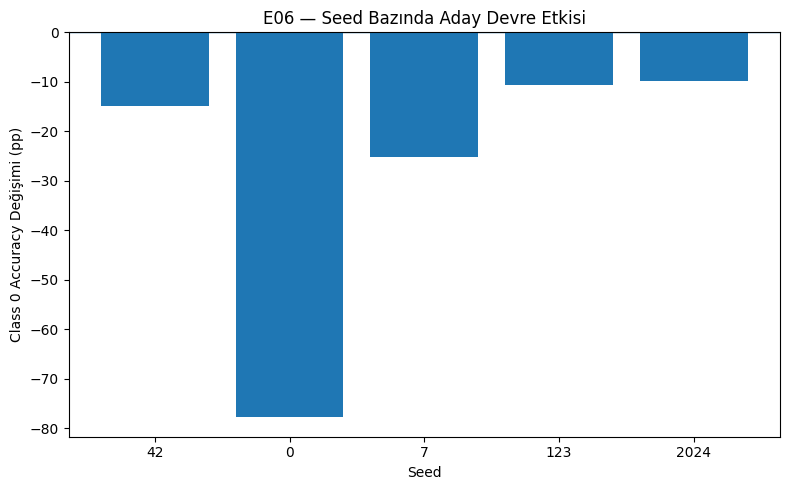

In [49]:
# ============================================================
# DENEY 6 — GRAFİK 1
# Amaç:
# Farklı seed değerlerinde aday devre ablasyonunun
# Class 0 doğruluğu üzerindeki etkisini karşılaştırmak.
# Negatif değer, ablasyon sonrası Class 0 doğruluğunun
# azaldığını gösterir.
# ============================================================

import matplotlib.pyplot as plt

seeds = [42, 0, 7, 123, 2024]

candidate_effects = [
    -14.8980,
    -77.8571,
    -25.2041,
    -10.6122,
    -9.7959
]

plt.figure(figsize=(8, 5))

plt.bar(
    [str(seed) for seed in seeds],
    candidate_effects
)

plt.axhline(0, linewidth=1)

plt.xlabel("Seed")
plt.ylabel("Class 0 Accuracy Değişimi (pp)")
plt.title("E06 — Seed Bazında Aday Devre Etkisi")

plt.tight_layout()
plt.show()

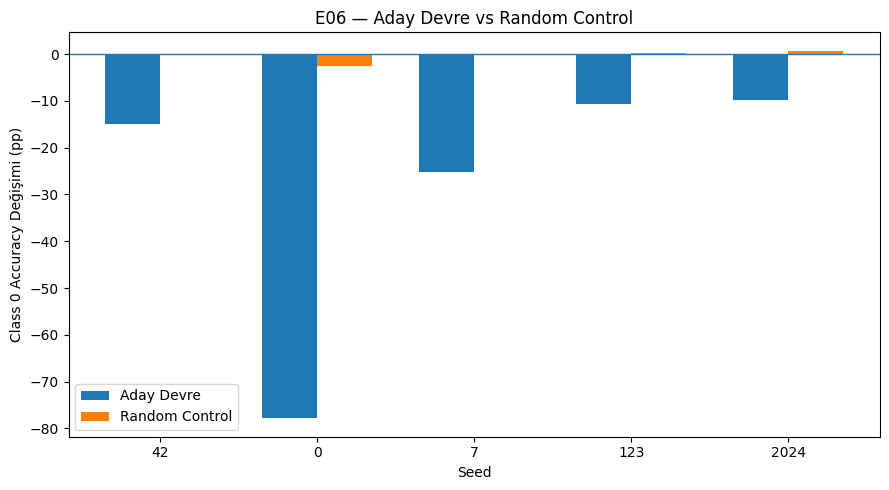

In [50]:
# ============================================================
# DENEY 6 — GRAFİK 2
# Amaç:
# Her seed için aday devre ablasyonu ile random control
# ablasyonunun Class 0 accuracy üzerindeki etkisini
# doğrudan karşılaştırmak.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

seeds = [42, 0, 7, 123, 2024]

candidate_effects = [
    -14.8980,
    -77.8571,
    -25.2041,
    -10.6122,
    -9.7959
]

random_effects = [
    0.1020,
    -2.5510,
    -0.3061,
    0.3061,
    0.7143
]

x = np.arange(len(seeds))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    candidate_effects,
    width,
    label="Aday Devre"
)

plt.bar(
    x + width / 2,
    random_effects,
    width,
    label="Random Control"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Seed")
plt.ylabel("Class 0 Accuracy Değişimi (pp)")
plt.title("E06 — Aday Devre vs Random Control")
plt.xticks(x, seeds)
plt.legend()

plt.tight_layout()
plt.show()

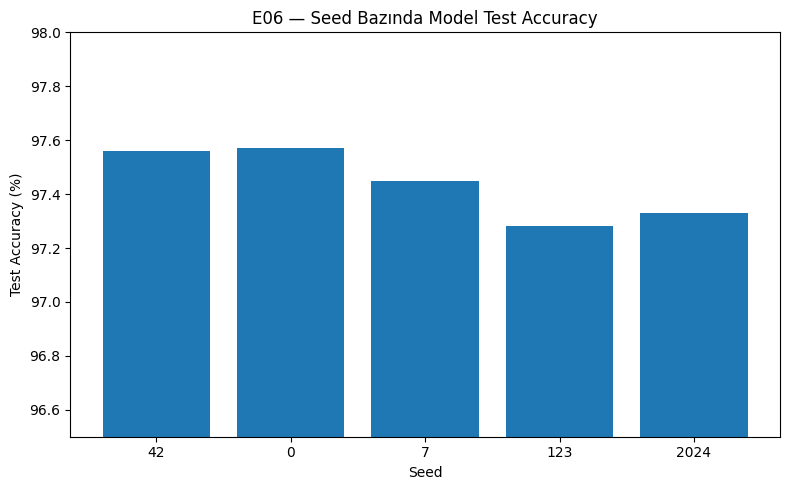

In [51]:
# ============================================================
# DENEY 6 — GRAFİK 3
# Amaç:
# Farklı seed değerlerinde modelin genel test doğruluğunun
# ne kadar stabil olduğunu göstermek.
# Bu grafik, ablasyon etkisinin modelin genel eğitim
# performansındaki büyük bir değişimden kaynaklanmadığını
# kontrol etmek için kullanılır.
# ============================================================

import matplotlib.pyplot as plt

seeds = [42, 0, 7, 123, 2024]

test_accuracies = [
    97.56,
    97.57,
    97.45,
    97.28,
    97.33
]

plt.figure(figsize=(8, 5))

plt.bar(
    [str(seed) for seed in seeds],
    test_accuracies
)

plt.xlabel("Seed")
plt.ylabel("Test Accuracy (%)")
plt.title("E06 — Seed Bazında Model Test Accuracy")

plt.ylim(96.5, 98.0)

plt.tight_layout()
plt.show()